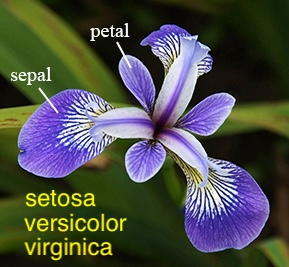
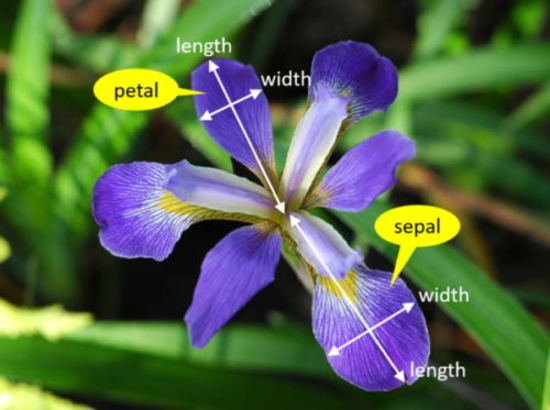
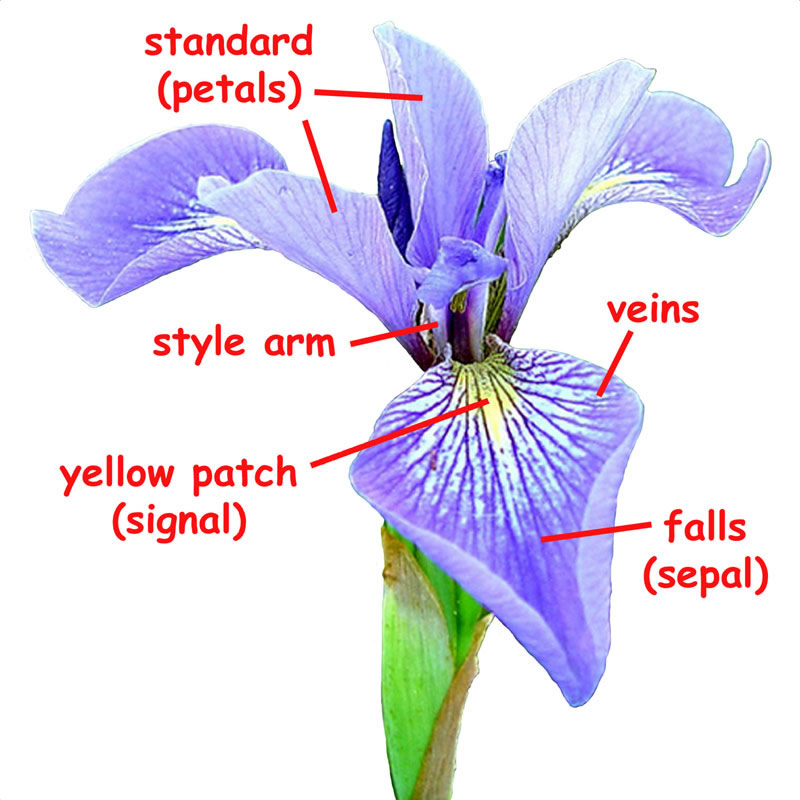

# Hier sieht man die Entscheidungsgrenzen für die drei Modelle (jeweils mit den ersten beiden Iris-Features: Sepal Length und Sepal Width):

## k-NN (k=5): Grenzen sind stückweise und „zerhackt“, weil die Klassenzuordnung von den Nachbarn abhängt.

## Logistic Regression: Grenzen sind linear (gerade Linien), da das Modell nur lineare Trennungen kann.

## Decision Tree: Grenzen sind rechteckig/stufig, da das Modell den Raum rekursiv aufteilt.

den Plot auch noch mit den anderen Features (Petal length & width) machen? Dort sieht man die Unterschiede zwischen den Algorithmen noch deutlicher, weil die Trennung viel klarer ist.

C:\0_DA\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


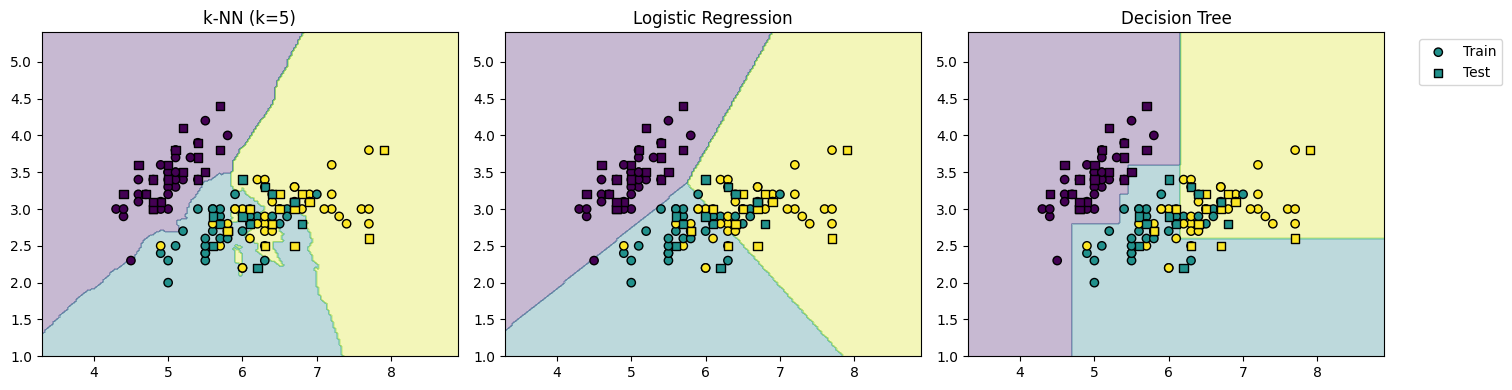

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Iris-Daten laden (nur 2 Features für die 2D-Darstellung)
iris = datasets.load_iris()
X = iris.data[:, :2]  # Sepal length & Sepal width
y = iris.target

# Split in Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

# Modelle definieren
models = [
    ("k-NN (k=5)", KNeighborsClassifier(n_neighbors=5)),
    ("Logistic Regression", LogisticRegression(max_iter=200, multi_class="multinomial")),
    ("Decision Tree", DecisionTreeClassifier(max_depth=4, random_state=42))
]

# Plot-Setup
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

plt.figure(figsize=(15, 4))

# Modelle trainieren und Grenzen plotten
for i, (name, model) in enumerate(models):
    model.fit(X_train, y_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", marker="o", label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", marker="s", label="Test")
    plt.title(name)

plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()


Jetzt sieht mandie Entscheidungsgrenzen für die Modelle mit den Features Petal Length und Petal Width:

k-NN (k=5): klare, aber stückweise Grenzen – reagiert lokal auf Nachbarschaft.

Logistic Regression: fast perfekte lineare Trennung zwischen den Klassen, hier sehr effizient.

Decision Tree: scharfe rechteckige Grenzen, die die Daten exakt aufteilen – kann aber leicht überfitten.

die Accuracy-Werte dieser drei Modelle auf den Iris-Daten direkt mit ausgebe, damit man die Unterschiede quantitativ sieht?

C:\0_DA\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


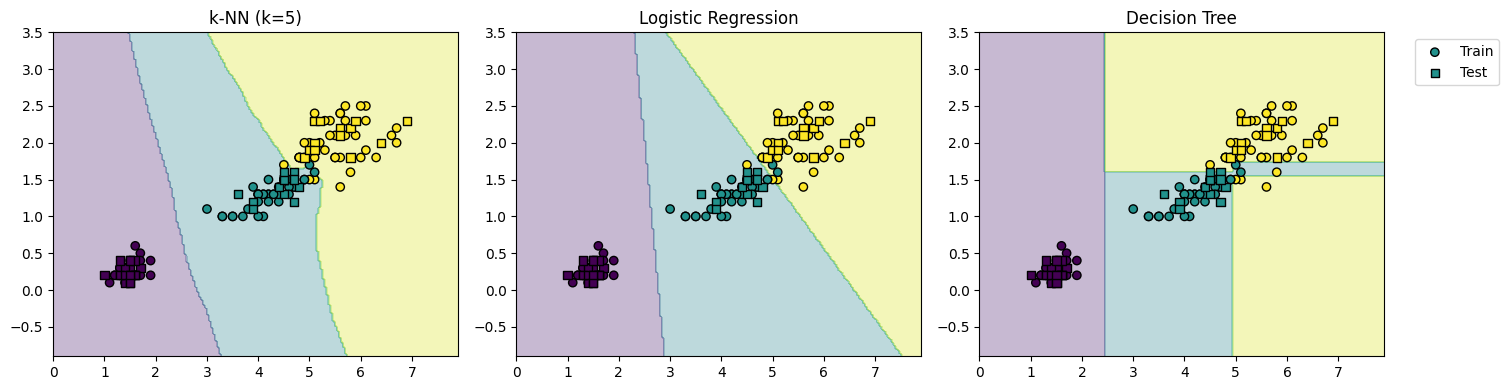

In [3]:
# Iris-Daten laden (diesmal Petal length & Petal width)
X = iris.data[:, 2:4]  # Petal length & Petal width
y = iris.target

# Split in Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

# Plot-Setup
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

plt.figure(figsize=(15, 4))

# Modelle trainieren und Grenzen plotten
for i, (name, model) in enumerate(models):
    model.fit(X_train, y_train)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor="k", marker="o", label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", marker="s", label="Test")
    plt.title(name)

plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()
